Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.8294 - loss: 0.4080 - val_accuracy: 0.9268 - val_loss: 0.1527
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9365 - loss: 0.1578 - val_accuracy: 0.9268 - val_loss: 0.1314
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9468 - loss: 0.1346 - val_accuracy: 0.9268 - val_loss: 0.0980
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - accuracy: 0.9599 - loss: 0.1076 - val_accuracy: 1.0000 - val_loss: 0.0557
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.9677 - loss: 0.0958 - val_accuracy: 1.0000 - val_loss: 0.0594
Epoch 6/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9683 - loss: 0.0863 - val_accuracy: 1.0000 - val_loss: 0.0278
Epoch 7/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.9676 - loss: 0.0844 - val_accuracy: 1.0000 - val_loss: 0.0380
Epoch 8/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9718 - loss: 0.0761 - val_accu

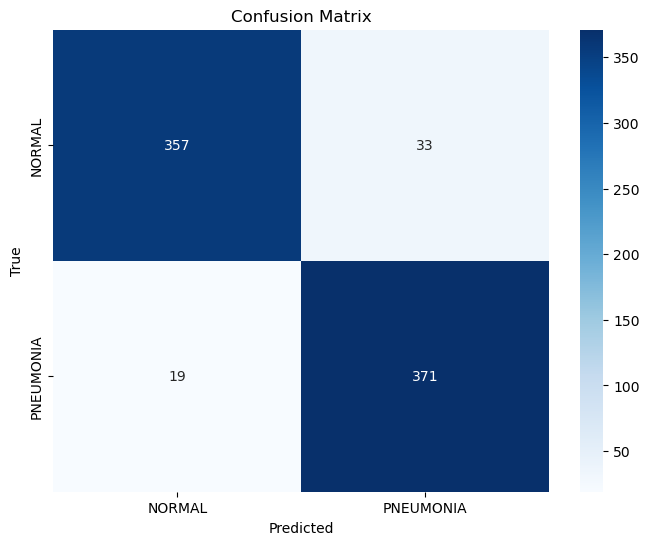

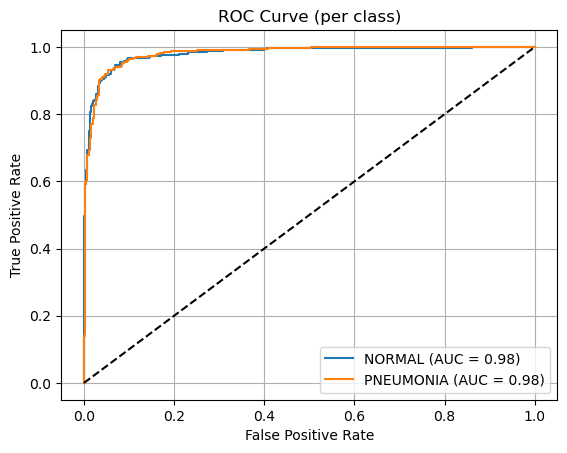

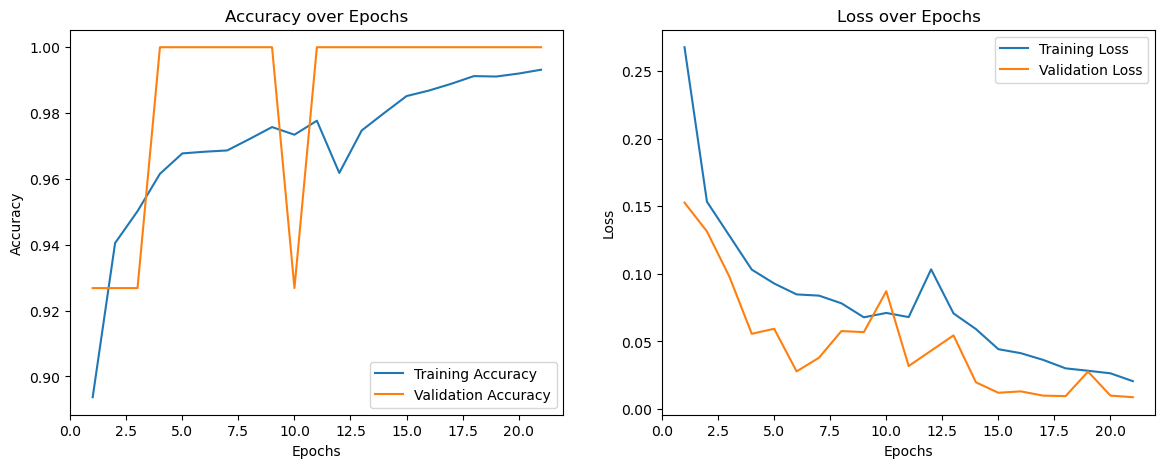

🔍 Classe: NORMAL — Accuracy: 0.92, F1-score: 0.48
🔍 Classe: PNEUMONIA — Accuracy: 0.95, F1-score: 0.49


In [3]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_1 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=15,
                      callbacks=[early_stop])
base_model.trainable = True

# Gèle les couches profondes sauf les dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=10,
                      callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])
for i, label in enumerate(target_names):
    class_indices = np.where(y_true == i)[0]
    class_y_pred = y_pred[class_indices]
    class_y_true = y_true[class_indices]
    class_f1 = f1_score(class_y_true, class_y_pred, average='macro')
    acc = np.mean(class_y_pred == class_y_true)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


In [9]:
from sklearn.metrics import f1_score, accuracy_score

for i, label in enumerate(target_names):
    class_y_true = (y_true == i).astype(int)
    class_y_pred = (y_pred == i).astype(int)
    class_f1 = f1_score(class_y_true, class_y_pred)
    acc = accuracy_score(class_y_true, class_y_pred)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


🔍 Classe: NORMAL — Accuracy: 0.93, F1-score: 0.93
🔍 Classe: PNEUMONIA — Accuracy: 0.93, F1-score: 0.93


In [5]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'ResNet50perfect_finetuned_model.h5'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


In [15]:
from PIL import Image
import os

def check_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)
                try:
                    img = Image.open(filepath)
                    img.verify()  # Vérifie si l'image est lisible
                except Exception as e:
                    print(f"Image corrompue : {filepath}")
                    os.remove(filepath)  # Supprime ou log les images corrompues

# Exécute ce script sur ton dossier d'entraînement et de validation
check_images('D:/Data-Chest-ray/train')
check_images('D:/Data-Chest-ray/val')
check_images('D:/Data-Chest-ray/test')


In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "D:/Data-Chest-ray/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "D:/Data-Chest-ray/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)


Found 7750 files belonging to 2 classes.
Found 328 files belonging to 2 classes.


Found 7750 images belonging to 2 classes.
Found 328 images belonging to 2 classes.
Found 780 images belonging to 2 classes.
Epoch 1/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - accuracy: 0.6349 - loss: 1.1848 - val_accuracy: 0.9848 - val_loss: 0.2622
Epoch 2/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.8595 - loss: 0.3322 - val_accuracy: 1.0000 - val_loss: 0.1644
Epoch 3/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.8964 - loss: 0.2555 - val_accuracy: 0.9268 - val_loss: 0.1681
Epoch 4/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.9207 - loss: 0.2176 - val_accuracy: 1.0000 - val_loss: 0.0882
Epoch 5/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.9296 - loss: 0.1852 - val_accuracy: 1.0000 - val_loss: 0.1004
Epoch 6/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.9363 - loss: 0.1812 - val_accuracy: 1.0000 - val_loss: 0.0895
Epoch 7/15
243/243 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.9381 - loss: 0.1578 - val_accuracy:

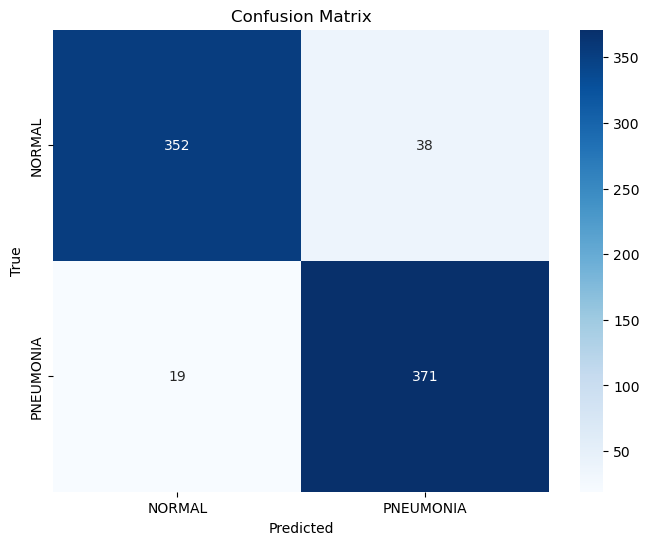

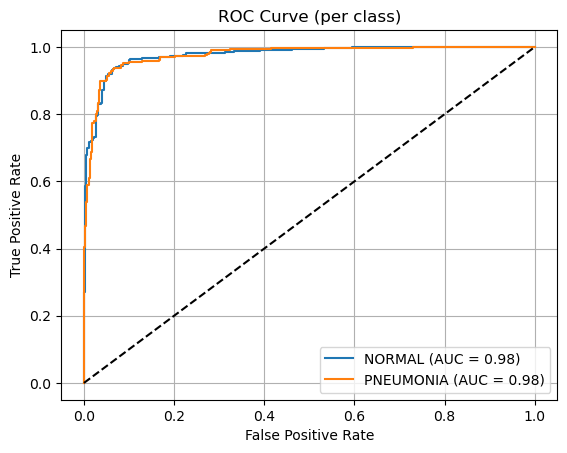

In [19]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_1 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=15,
                      callbacks=[early_stop])
base_model.trainable = True

# Gèle les couches profondes sauf les dernières
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_2 = model.fit(train_gen,
                      validation_data=val_gen,
                      epochs=10,
                      callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

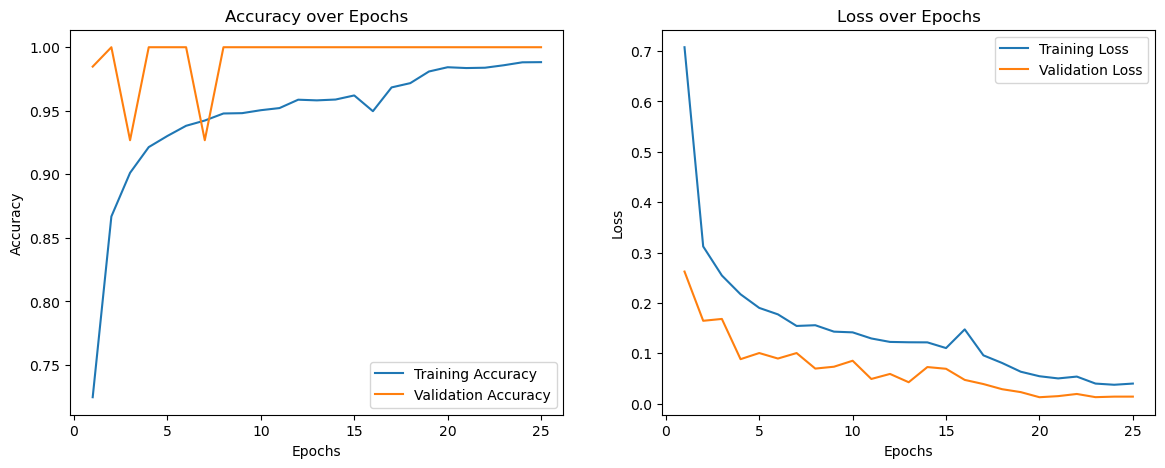

In [21]:
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])


In [23]:
from sklearn.metrics import f1_score, accuracy_score

for i, label in enumerate(target_names):
    class_y_true = (y_true == i).astype(int)
    class_y_pred = (y_pred == i).astype(int)
    class_f1 = f1_score(class_y_true, class_y_pred)
    acc = accuracy_score(class_y_true, class_y_pred)
    print(f"🔍 Classe: {label} — Accuracy: {acc:.2f}, F1-score: {class_f1:.2f}")


🔍 Classe: NORMAL — Accuracy: 0.93, F1-score: 0.93
🔍 Classe: PNEUMONIA — Accuracy: 0.93, F1-score: 0.93


In [25]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'ResNet500.7perfect_finetuned_model.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.
